In [1]:
"""
=================================================
Blind IRF estimation from a fluorescence decay
=================================================

A time-resolved measurement is the fluorescence decay convolved with the
instrument response function (IRF). Fitting lifetimes therefore needs the IRF,
which is usually measured separately with a scattering sample -- a second
measurement that is easy to forget, drifts with the laser and the detector, and
is not available at all for archived data.

*Blind IRF identification from fluorescence decays* (BIRFI, Gómez-Sánchez et al.,
Biophysical Reports 2024; reference implementation `VicidominiLab/birfi
<https://github.com/VicidominiLab/birfi>`_) infers the IRF from the decay
itself, without any scatter measurement:

1. a Savitzky-Golay derivative finds the decay region of every channel;
2. one **shared decay rate** ``k`` with per-channel amplitude ``A`` and
   background ``C`` is fitted to the tails (``A exp(-k t) + C``); tttrlib solves
   this model exactly (per-``k`` linear ``A, C``, golden section over ``k``)
   where the reference iterates it with Adam;
3. a normalised exponential kernel with that rate is built;
4. **periodic** Richardson-Lucy deconvolution of the background-subtracted
   decay by the kernel returns the IRF, regularised by a small median filter.

The estimate is what a mono-exponential decay through the instrument looks like
once the exponential is divided out. It works for a single dominant lifetime
(the reference case, e.g. a dye standard, or a FRET-free donor channel) and for
array detectors, where every element gets its own IRF but the rate is shared.

``tttrlib.blind_irf_estimate`` is bit-for-bit validated against ``birfi`` and
runs several times faster (see PERF.md). This example simulates the measurement
so the truth is known.
"""

'\n=================================================\nBlind IRF estimation from a fluorescence decay\n=================================================\n\nA time-resolved measurement is the fluorescence decay convolved with the\ninstrument response function (IRF). Fitting lifetimes therefore needs the IRF,\nwhich is usually measured separately with a scattering sample -- a second\nmeasurement that is easy to forget, drifts with the laser and the detector, and\nis not available at all for archived data.\n\n*Blind IRF identification from fluorescence decays* (BIRFI, Gómez-Sánchez et al.,\nBiophysical Reports 2024; reference implementation `VicidominiLab/birfi\n<https://github.com/VicidominiLab/birfi>`_) infers the IRF from the decay\nitself, without any scatter measurement:\n\n1. a Savitzky-Golay derivative finds the decay region of every channel;\n2. one **shared decay rate** ``k`` with per-channel amplitude ``A`` and\n   background ``C`` is fitted to the tails (``A exp(-k t) + C``); tt

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import tttrlib

rng = np.random.default_rng(3)

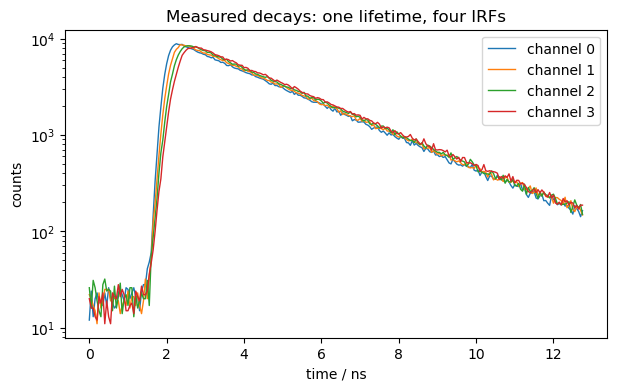

In [3]:
# The instrument and the sample
# -----------------------------
# 256 micro-time channels of 50 ps, an excitation period of 12.8 ns, and a
# mono-exponential decay of 2.5 ns. Four detector channels see the same decay
# through slightly different IRFs -- a later, wider one for each -- which is
# the array-detector situation the method was made for.
n_bins, dt = 256, 0.05                       # ns
t = np.arange(n_bins) * dt
tau_true = 2.5                               # ns
n_channels = 4
photons = 5e5                                # per channel
background = 20                              # counts per bin

true_irf = np.zeros((n_bins, n_channels))
data = np.zeros((n_bins, n_channels))
for c in range(n_channels):
    centre = 2.0 + 0.10 * c                  # ns
    sigma = 0.15 + 0.03 * c                  # ns
    irf = np.exp(-0.5 * ((t - centre) / sigma) ** 2)
    irf /= irf.sum()
    true_irf[:, c] = irf
    model = np.convolve(irf, np.exp(-t / tau_true))[:n_bins]
    data[:, c] = rng.poisson(model / model.sum() * photons + background)

fig, ax = plt.subplots(figsize=(7, 4))
for c in range(n_channels):
    ax.semilogy(t, data[:, c], lw=1, label=f"channel {c}")
ax.set_xlabel("time / ns")
ax.set_ylabel("counts")
ax.set_title("Measured decays: one lifetime, four IRFs")
ax.legend()
plt.show()

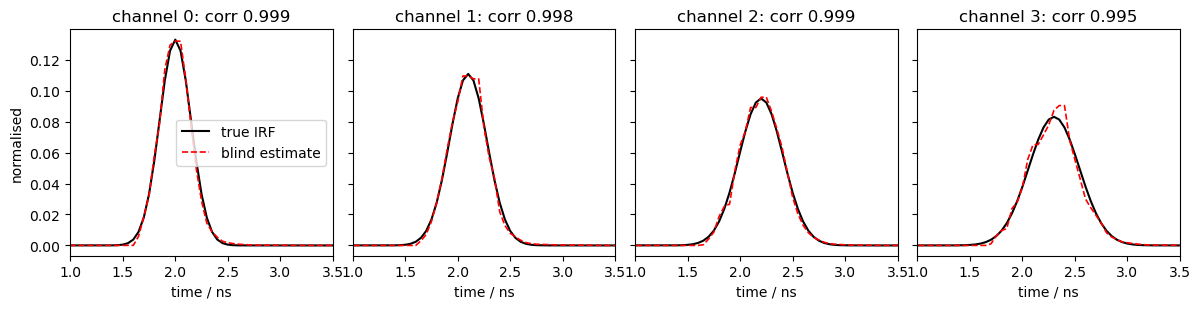

In [4]:
# The estimate
# ------------
# The data is an (n_bins x n_channels) array; the estimated IRFs come back
# with the same shape. 500 Richardson-Lucy iterations, a 3-bin median filter,
# and an 11-point cubic Savitzky-Golay window are the reference's defaults.
# (``blind_irf_estimate`` is the same kernel on a flat list, for the other
# language bindings.)
estimate = np.asarray(tttrlib.blind_irf_estimate_array(
    data, dt,
    500,        # RL iterations
    3,          # median-filter window (regularisation)
    11, 3,      # Savitzky-Golay window and polynomial order
))
estimate /= estimate.sum(axis=0, keepdims=True)

fig, axes = plt.subplots(1, n_channels, figsize=(12, 3.2), sharey=True)
for c, ax in enumerate(axes):
    ax.plot(t, true_irf[:, c], "k-", lw=1.5, label="true IRF")
    ax.plot(t, estimate[:, c], "r--", lw=1.2, label="blind estimate")
    ax.set_xlim(1.0, 3.5)
    ax.set_xlabel("time / ns")
    corr = np.corrcoef(true_irf[:, c], estimate[:, c])[0, 1]
    ax.set_title(f"channel {c}: corr {corr:.3f}")
axes[0].set_ylabel("normalised")
axes[0].legend()
plt.tight_layout()
plt.show()

In [5]:
# The estimate is not a fit of a Gaussian: it is the deconvolved data, so it
# carries the ringing of any deconvolution -- small side lobes on either side of
# the peak -- and its width is the true width plus a fraction of a bin. What it
# gets right is what a lifetime fit needs: the position and the shape of the
# rising edge.
for c in range(n_channels):
    print(f"channel {c}: true peak {t[np.argmax(true_irf[:, c])]:.2f} ns, "
          f"estimated {t[np.argmax(estimate[:, c])]:.2f} ns; "
          f"mass within +-0.5 ns of the peak {estimate[np.abs(t - t[np.argmax(true_irf[:, c])]) < 0.5, c].sum():.3f}")

channel 0: true peak 2.00 ns, estimated 2.00 ns; mass within +-0.5 ns of the peak 0.994
channel 1: true peak 2.10 ns, estimated 2.05 ns; mass within +-0.5 ns of the peak 0.990
channel 2: true peak 2.20 ns, estimated 2.20 ns; mass within +-0.5 ns of the peak 0.981
channel 3: true peak 2.30 ns, estimated 2.35 ns; mass within +-0.5 ns of the peak 0.958


In [6]:
# Using the recovered IRF in a lifetime fit
# -----------------------------------------
# The point of the exercise: reconvolution fits with the blind IRF recover the
# lifetime as well as fits with the true one. ``FitNExp`` is the bounded
# multi-exponential maximum-likelihood fitter; each channel is fitted with its
# own estimated IRF, and again with the true one for comparison.
period = n_bins * dt
print("\nlifetime from a reconvolution fit:")
for c in range(n_channels):
    for name, irf in (("true IRF", true_irf[:, c]), ("blind IRF", estimate[:, c])):
        fitter = tttrlib.FitNExp(dt=dt, irf=irf, period=period, tau_min=0.1, tau_max=10.0)
        res = fitter(data[:, c], initial_lifetimes=[1.0])
        print(f"  channel {c}, {name:9s}: tau = {res['lifetimes'][0]:.3f} ns "
              f"(true {tau_true})")


lifetime from a reconvolution fit:
  channel 0, true IRF : tau = 2.450 ns (true 2.5)
  channel 0, blind IRF: tau = 2.449 ns (true 2.5)
  channel 1, true IRF : tau = 2.454 ns (true 2.5)
  channel 1, blind IRF: tau = 2.452 ns (true 2.5)
  channel 2, true IRF : tau = 2.438 ns (true 2.5)
  channel 2, blind IRF: tau = 2.439 ns (true 2.5)
  channel 3, true IRF : tau = 2.437 ns (true 2.5)
  channel 3, blind IRF: tau = 2.442 ns (true 2.5)


In [7]:
# When it does not apply
# ----------------------
# The rate is fitted to the tail of the decay, so a **multi-exponential**
# sample makes the kernel wrong and the "IRF" absorbs the second component
# (it will look like a peak with a slow shoulder). Use a scatter measurement or a
# dye standard, or restrict the estimate to a channel that is known to be
# mono-exponential -- a FRET-free donor, a lifetime standard -- and apply that IRF
# to the rest, as the reference paper does.